# Pet Breed Classification with Transfer Learning

This notebook studies fine-grained classification of **37 cat and dog breeds** from the Oxford-IIIT Pet Dataset. A pretrained ResNet18 is evaluated under frozen-feature training, partial and full fine-tuning, BatchNorm-statistics control, Grad-CAM interpretation, and mixup regularization.

The experiments intentionally use a small balanced subset: 20 training and 8 validation images per breed. This makes the comparison computationally practical while exposing the trade-offs of adapting a large pretrained model with limited data.

## 1. Setup and reproducibility

In [20]:
from copy import deepcopy
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
DATA_ROOT = Path("data")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
print(f"Using device: {DEVICE}")

Using device: mps


## 2. Balanced Oxford-IIIT Pet subset

The dataset is downloaded through `torchvision`. Class-balanced indices and deterministic seeds keep every experiment comparable.

In [21]:
raw_trainval = OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True, transform=None)
raw_test_full = OxfordIIITPet(root=DATA_ROOT, split="test", download=True, transform=None)

print(len(raw_trainval.classes),raw_trainval.classes[:5])
print(len(raw_trainval), len(raw_test_full))


37 ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']
3680 3669


In [22]:
def make_balanced_indices(labels, n_per_class, seed=SEED):
    rng = random.Random(seed)
    buckets = {}
    for index, label in enumerate(labels):
        if label not in buckets:
            buckets[label] = []
        buckets[label].append(index)

    selected = []
    for label in sorted(buckets):
        rng.shuffle(buckets[label])
        selected.extend(buckets[label][:n_per_class])

    return selected


train_indices = make_balanced_indices(raw_trainval._labels, n_per_class=20, seed=SEED)
val_indices = make_balanced_indices(raw_test_full._labels, n_per_class=8, seed=SEED)

class_names = raw_trainval.classes
NUM_CLASSES = len(class_names)
print("Classes:", NUM_CLASSES)
print("Train images:", len(train_indices), "| Val images:", len(val_indices))

Classes: 37
Train images: 740 | Val images: 296


In [23]:
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_index = self.indices[idx]
        image, label = self.base_dataset[real_index]
        image = self.transform(image)
        return image, label


deterministic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = TransformSubset(raw_trainval, train_indices, deterministic_transform)
val_dataset = TransformSubset(raw_test_full, val_indices, deterministic_transform)
print(len(train_dataset))
img, lbl = train_dataset[0]
print(img.shape, lbl)

740
torch.Size([3, 224, 224]) 0


### Sample images

Several breeds share color, coat, and face structure. Distinguishing them requires local cues such as ear shape, muzzle length, and coat texture.

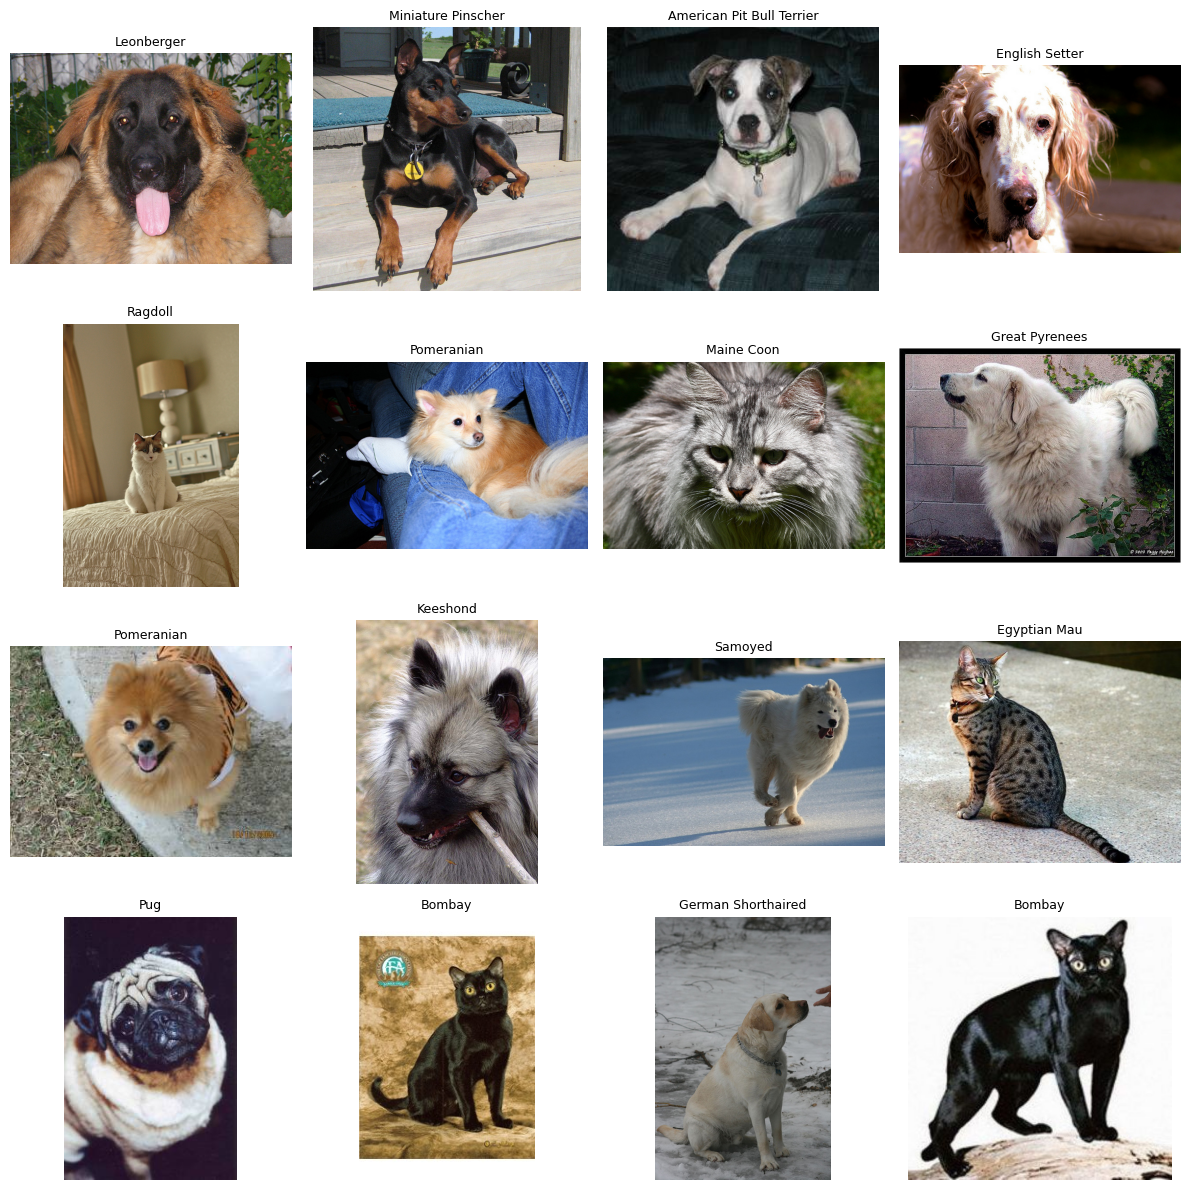

In [24]:
view_rng = random.Random(0)
sample_positions = view_rng.sample(range(len(train_indices)), 16)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, pos in zip(axes.flat, sample_positions):
    image, label = raw_trainval[train_indices[pos]]
    ax.imshow(image)
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Frozen-feature baseline

The ImageNet backbone is frozen and replaced with a 37-output linear classifier. Only the new head is optimized.

In [25]:
def make_loader(dataset, shuffle, batch_size=16, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, generator=generator)


def run_epoch(model, loader, loss_fn, optimizer=None):
    is_training = optimizer is not None
    model.eval()
    if is_training:
        # Only the parts of the model actually being trained go into train() mode.
        # Only explicitly trainable modules enter training mode.
        for module in model.trainable_modules:
            module.train()

    total_loss, total_correct, total_examples = 0.0, 0, 0
    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}

In [26]:
weights = ResNet18_Weights.DEFAULT

feature_model = resnet18(weights=weights)
for parameter in feature_model.parameters():
    parameter.requires_grad = False
num_features = feature_model.fc.in_features
feature_model.fc = nn.Linear(num_features, NUM_CLASSES)
feature_model = feature_model.to(DEVICE)
feature_model.trainable_modules = [feature_model.fc]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset_aug = TransformSubset(raw_trainval, train_indices, train_transform)
train_loader = make_loader(train_dataset_aug, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)

optimizer = torch.optim.Adam(feature_model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

frozen_history = {"train_accuracy": [], "val_accuracy": []}
EPOCHS = 8
for epoch in range(EPOCHS):
    train_metrics = run_epoch(feature_model, train_loader, loss_fn, optimizer=optimizer)
    val_metrics = run_epoch(feature_model, val_loader, loss_fn)
    frozen_history["train_accuracy"].append(train_metrics["accuracy"])
    frozen_history["val_accuracy"].append(val_metrics["accuracy"])
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train acc: {train_metrics['accuracy']:.1%} | val acc: {val_metrics['accuracy']:.1%}")

Epoch 01/8 | train acc: 25.7% | val acc: 52.4%
Epoch 02/8 | train acc: 76.9% | val acc: 72.6%
Epoch 03/8 | train acc: 84.9% | val acc: 80.7%
Epoch 04/8 | train acc: 92.0% | val acc: 82.4%
Epoch 05/8 | train acc: 93.8% | val acc: 81.4%
Epoch 06/8 | train acc: 95.5% | val acc: 80.7%
Epoch 07/8 | train acc: 96.8% | val acc: 84.5%
Epoch 08/8 | train acc: 97.3% | val acc: 86.1%


The frozen-feature baseline reaches **86.1%** validation accuracy. Its final training accuracy is **97.3%**, indicating a noticeable generalization gap despite training only the classifier head.

## 4. Selective fine-tuning

The classifier head uses a learning rate of `1e-3`, while pretrained backbone parameters use `1e-5`. Three configurations are compared: head only, `layer4` plus head, and the full network.

In [27]:
def make_finetune_model(unfreeze_from, head_lr=1e-3, backbone_lr=1e-5):
    '''Return (model, optimizer). `model.trainable_modules` is set so that
    run_epoch's train()/eval() bookkeeping stays correct.'''
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)


    for parameter in model.parameters():
        parameter.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, NUM_CLASSES)
    # A freshly created nn.Linear is trainable by default -- no action needed for the head.

    param_groups = [{"params": model.fc.parameters(), "lr": head_lr}]
    trainable_modules = [model.fc]

    if unfreeze_from in ("layer4", "all"):
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

        param_groups.append({
            "params": model.layer4.parameters(),
            "lr": backbone_lr,
        })
        trainable_modules.append(model.layer4)

    if unfreeze_from == "all":
        remaining_modules = [
            model.conv1,
            model.bn1,
            model.layer1,
            model.layer2,
            model.layer3,
        ]

        remaining_parameters = []

        for module in remaining_modules:
            for parameter in module.parameters():
                parameter.requires_grad = True
                remaining_parameters.append(parameter)

        param_groups.append({
            "params": remaining_parameters,
            "lr": backbone_lr,
        })

        trainable_modules.extend(remaining_modules)


    model = model.to(DEVICE)
    model.trainable_modules = trainable_modules
    optimizer = torch.optim.Adam(param_groups)
    return model, optimizer

### Parameter-group verification

In [28]:
probe_model, probe_optimizer = make_finetune_model("layer4")

total_params = sum(p.numel() for p in probe_model.parameters())
print("Total parameters:", total_params)

optimizer_params = 0

for i, group in enumerate(probe_optimizer.param_groups):
    count = sum(p.numel() for p in group["params"])
    optimizer_params += count
    print(f"Group {i}: lr={group['lr']} | parameters={count}")

trainable_params = sum(
    p.numel()
    for p in probe_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)
print("Optimizer parameters:", optimizer_params)

assert optimizer_params == trainable_params, "Parameter counts do not match!"

Total parameters: 11195493
Group 0: lr=0.001 | parameters=18981
Group 1: lr=1e-05 | parameters=8393728
Trainable parameters: 8412709
Optimizer parameters: 8412709


### Frozen, partial, and full fine-tuning

  none | Epoch 01/8 | train acc: 25.7% | val acc: 52.4%
  none | Epoch 02/8 | train acc: 76.9% | val acc: 72.6%
  none | Epoch 03/8 | train acc: 84.9% | val acc: 80.7%
  none | Epoch 04/8 | train acc: 92.0% | val acc: 82.4%
  none | Epoch 05/8 | train acc: 93.8% | val acc: 81.4%
  none | Epoch 06/8 | train acc: 95.5% | val acc: 80.7%
  none | Epoch 07/8 | train acc: 96.8% | val acc: 84.5%
  none | Epoch 08/8 | train acc: 97.3% | val acc: 86.1%
Best none val accuracy: 86.1%

layer4 | Epoch 01/8 | train acc: 20.9% | val acc: 49.0%
layer4 | Epoch 02/8 | train acc: 71.4% | val acc: 70.6%
layer4 | Epoch 03/8 | train acc: 84.6% | val acc: 81.8%
layer4 | Epoch 04/8 | train acc: 90.1% | val acc: 81.1%
layer4 | Epoch 05/8 | train acc: 92.3% | val acc: 83.1%
layer4 | Epoch 06/8 | train acc: 94.5% | val acc: 82.4%
layer4 | Epoch 07/8 | train acc: 96.5% | val acc: 86.5%
layer4 | Epoch 08/8 | train acc: 98.0% | val acc: 85.1%
Best layer4 val accuracy: 86.5%

   all | Epoch 01/8 | train acc: 20.1% |

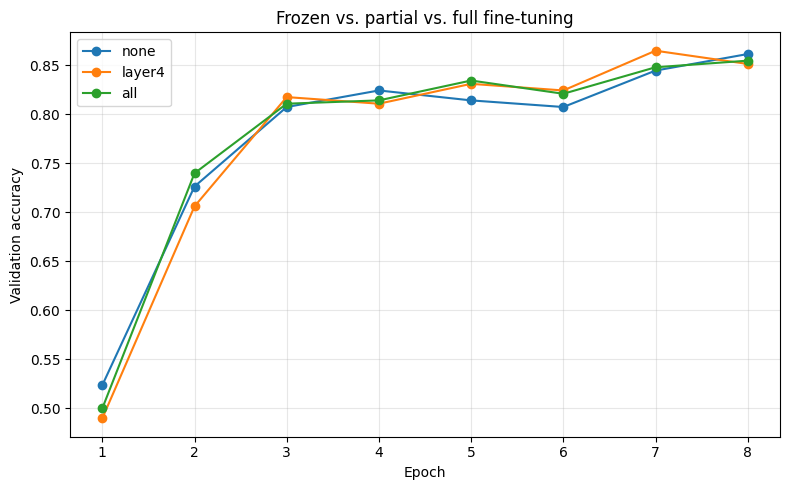

In [30]:
comparison_histories = {}
comparison_models = {}

for unfreeze_from in ["none", "layer4", "all"]:
    set_seed(SEED)
    current_train_loader = make_loader(train_dataset_aug, shuffle=True, seed=SEED)
    model, optimizer = make_finetune_model(unfreeze_from)
    history = {"train_accuracy": [], "val_accuracy": []}
    best_val_accuracy = -1.0
    best_state = None

    for epoch in range(EPOCHS):
        train_metrics = run_epoch(model, current_train_loader, loss_fn, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, loss_fn)
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            best_state = deepcopy(model.state_dict())

        print(
            f"{unfreeze_from:>6} | Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"train acc: {train_metrics['accuracy']:.1%} | "
            f"val acc: {val_metrics['accuracy']:.1%}"
        )

    model.load_state_dict(best_state)
    comparison_histories[unfreeze_from] = history
    comparison_models[unfreeze_from] = model
    print(f"Best {unfreeze_from} val accuracy: {best_val_accuracy:.1%}\n")

plt.figure(figsize=(8, 5))
for unfreeze_from, history in comparison_histories.items():
    plt.plot(
        range(1, EPOCHS + 1),
        history["val_accuracy"],
        marker="o",
        label=unfreeze_from,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Frozen vs. partial vs. full fine-tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Partial `layer4` fine-tuning performs best among these three runs at **86.5%**. Full fine-tuning reaches **85.5%**, suggesting that 740 images are insufficient to safely adapt all 11.2 million parameters.

### BatchNorm running-statistics comparison

Convolution weights in `layer4` remain trainable, but its BatchNorm modules can be returned to evaluation mode so their ImageNet running mean and variance remain fixed.

In [29]:
def run_epoch_bn_frozen(model, loader, loss_fn, optimizer=None, frozen_bn_module=None):
    is_training = optimizer is not None
    model.eval()
    if is_training:
        for module in model.trainable_modules:
            module.train()
        if frozen_bn_module is not None:
            for module in frozen_bn_module.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()

    total_loss, total_correct, total_examples = 0.0, 0, 0
    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


set_seed(SEED)
bn_frozen_loader = make_loader(train_dataset_aug, shuffle=True, seed=SEED)
model_b, optimizer_b = make_finetune_model("layer4")
bn_frozen_history = []
best_bn_frozen_state = None
best_bn_frozen_accuracy = -1.0

for epoch in range(EPOCHS):
    run_epoch_bn_frozen(
        model_b,
        bn_frozen_loader,
        loss_fn,
        optimizer=optimizer_b,
        frozen_bn_module=model_b.layer4,
    )
    val_metrics = run_epoch_bn_frozen(model_b, val_loader, loss_fn)
    bn_frozen_history.append(val_metrics["accuracy"])
    if val_metrics["accuracy"] > best_bn_frozen_accuracy:
        best_bn_frozen_accuracy = val_metrics["accuracy"]
        best_bn_frozen_state = deepcopy(model_b.state_dict())
    print(f"Epoch {epoch + 1:02d}/{EPOCHS} | val acc: {val_metrics['accuracy']:.1%}")

model_b.load_state_dict(best_bn_frozen_state)
normal_bn_best = max(comparison_histories["layer4"]["val_accuracy"])
print(f"Best layer4 accuracy with updating BN stats: {normal_bn_best:.1%}")
print(f"Best layer4 accuracy with frozen BN stats: {best_bn_frozen_accuracy:.1%}")


Epoch 01/8 | val acc: 59.8%
Epoch 02/8 | val acc: 77.7%
Epoch 03/8 | val acc: 76.0%
Epoch 04/8 | val acc: 85.1%
Epoch 05/8 | val acc: 81.4%
Epoch 06/8 | val acc: 84.1%
Epoch 07/8 | val acc: 86.8%
Epoch 08/8 | val acc: 87.2%
Best layer4 accuracy with updating BN stats: 86.5%
Best layer4 accuracy with frozen BN stats: 87.2%


Keeping the pretrained BatchNorm running statistics fixed improves the best validation accuracy from **86.5%** to **87.2%**. With small batches and only 740 training images, newly estimated activation statistics can be noisy.

## 5. Grad-CAM interpretation

Grad-CAM weights each final convolutional feature map by the spatially averaged gradient of a selected class score, then applies ReLU to retain positive evidence.

In [31]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        def save_activations(module, inputs, output):
            self.activations = output.detach()

        def save_gradients(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.forward_handle = target_layer.register_forward_hook(save_activations)
        self.backward_handle = target_layer.register_full_backward_hook(save_gradients)

    def __call__(self, input_tensor, class_index=None):
        '''Run one image (shape [1, 3, 224, 224]) through the model and
        return a single-channel heatmap of shape [H, W] (same H, W as the
        target layer's activation maps).'''
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None
        logits = self.model(input_tensor)

        if class_index is None:
            class_index = logits.argmax(dim=1).item()

        logits[0, class_index].backward()

        if self.activations is None or self.gradients is None:
            raise RuntimeError("Grad-CAM hooks did not capture activations and gradients.")

        alpha = self.gradients.mean(dim=(2, 3))[0]
        heatmap = (alpha[:, None, None] * self.activations[0]).sum(dim=0)
        heatmap = torch.relu(heatmap)
        heatmap = heatmap - heatmap.min()

        max_value = heatmap.max()
        if max_value.item() > 0:
            heatmap = heatmap / max_value

        return heatmap.cpu().numpy()

    def remove(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

### Correct baseline predictions

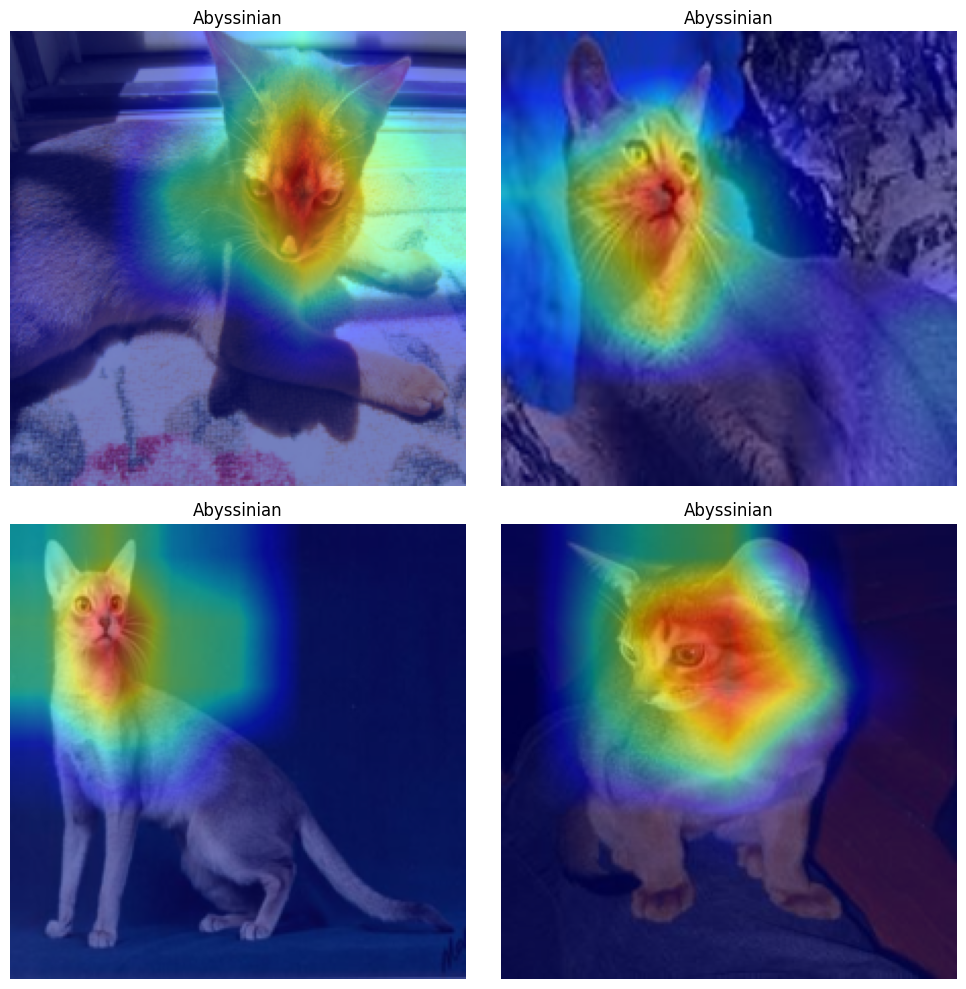

In [32]:
import torch.nn.functional as F

if "gradcam" in globals():
    gradcam.remove()
gradcam = GradCAM(feature_model, feature_model.layer4)

def overlay_heatmap(image_tensor, heatmap, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_tensor = torch.tensor(mean, dtype=image_tensor.dtype, device=image_tensor.device)[:, None, None]
    std_tensor = torch.tensor(std, dtype=image_tensor.dtype, device=image_tensor.device)[:, None, None]
    image = image_tensor.detach() * std_tensor + mean_tensor
    image = image.permute(1, 2, 0).clamp(0, 1).cpu().numpy()

    heatmap_tensor = torch.as_tensor(heatmap, dtype=torch.float32)[None, None]
    resized_heatmap = F.interpolate(
        heatmap_tensor,
        size=image.shape[:2],
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()

    plt.imshow(image)
    plt.imshow(resized_heatmap, cmap="jet", alpha=0.5)
    plt.axis("off")


correct_examples = []
feature_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        predictions = feature_model(images.to(DEVICE)).argmax(dim=1).cpu()
        for image, label, prediction in zip(images, labels, predictions):
            if prediction.item() == label.item():
                correct_examples.append((image, label.item(), prediction.item()))
            if len(correct_examples) == 4:
                break
        if len(correct_examples) == 4:
            break

if len(correct_examples) < 4:
    raise RuntimeError("Fewer than four correct validation predictions were found.")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (image, label, prediction) in zip(axes.flat, correct_examples):
    single_image = image.unsqueeze(0).to(DEVICE).clone().requires_grad_(True)
    heatmap = gradcam(single_image, class_index=prediction)
    plt.sca(ax)
    overlay_heatmap(image, heatmap)
    ax.set_title(class_names[label])

plt.tight_layout()
plt.show()

### Frozen versus fine-tuned attention

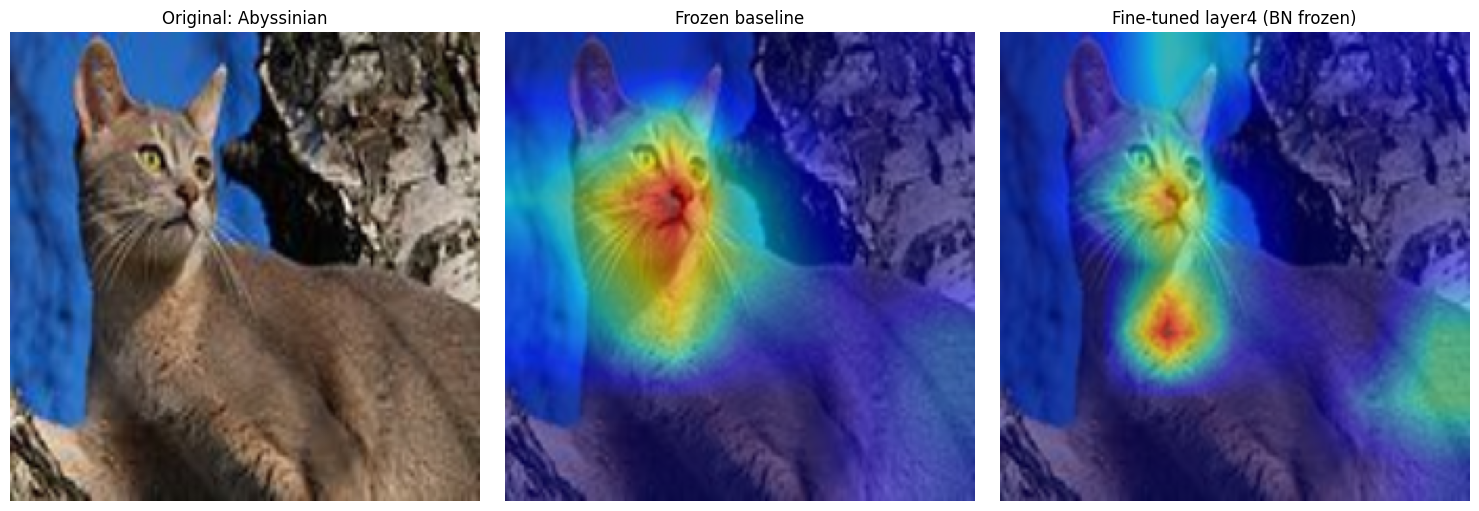

Selected class: Abyssinian | heatmap difference: 0.128


In [33]:
# Compare Grad-CAM for the frozen baseline and the best fine-tuned model
finetuned_model = model_b if "model_b" in globals() else comparison_models["layer4"]
finetuned_name = "Fine-tuned layer4 (BN frozen)" if "model_b" in globals() else "Fine-tuned layer4"

if "gradcam" in globals():
    gradcam.remove()
baseline_gradcam = GradCAM(feature_model, feature_model.layer4)
finetuned_gradcam = GradCAM(finetuned_model, finetuned_model.layer4)

# Keep images that both models classify correctly, then select the pair of
# heatmaps with the largest mean absolute difference.
cam_candidates = []
feature_model.eval()
finetuned_model.eval()

for images, labels in val_loader:
    images_device = images.to(DEVICE)
    labels_device = labels.to(DEVICE)
    with torch.no_grad():
        baseline_predictions = feature_model(images_device).argmax(dim=1)
        finetuned_predictions = finetuned_model(images_device).argmax(dim=1)
    correct_for_both = (baseline_predictions == labels_device) & (finetuned_predictions == labels_device)

    for index in torch.where(correct_for_both)[0].tolist():
        image = images[index]
        label = int(labels[index])
        grad_input = image.unsqueeze(0).to(DEVICE).clone().requires_grad_(True)
        baseline_heatmap = baseline_gradcam(grad_input, class_index=label)
        finetuned_heatmap = finetuned_gradcam(grad_input, class_index=label)
        difference = float(np.mean(np.abs(baseline_heatmap - finetuned_heatmap)))
        cam_candidates.append((difference, image, label, baseline_heatmap, finetuned_heatmap))
        if len(cam_candidates) >= 12:
            break
    if len(cam_candidates) >= 12:
        break

if not cam_candidates:
    raise RuntimeError("No validation image was classified correctly by both models.")

difference, selected_image, selected_label, baseline_heatmap, finetuned_heatmap = max(
    cam_candidates, key=lambda item: item[0]
)

mean_tensor = torch.tensor(IMAGENET_MEAN)[:, None, None]
std_tensor = torch.tensor(IMAGENET_STD)[:, None, None]
display_image = (selected_image * std_tensor + mean_tensor).permute(1, 2, 0).clamp(0, 1).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(display_image)
axes[0].set_title(f"Original: {class_names[selected_label]}")
axes[0].axis("off")
plt.sca(axes[1])
overlay_heatmap(selected_image, baseline_heatmap)
axes[1].set_title("Frozen baseline")
plt.sca(axes[2])
overlay_heatmap(selected_image, finetuned_heatmap)
axes[2].set_title(finetuned_name)
plt.tight_layout()
plt.show()

print(f"Selected class: {class_names[selected_label]} | heatmap difference: {difference:.3f}")
baseline_gradcam.remove()
finetuned_gradcam.remove()


For the selected Abyssinian image, the frozen model emphasizes a broad face-and-neck region. The fine-tuned model retains a smaller facial focus and adds attention over the chest and coat, demonstrating that fine-tuning changes the spatial evidence used for classification.

## 6. Mixup regularization

Mixup creates virtual samples as $\tilde{x}=\lambda x_i+(1-\lambda)x_j$ and trains against both labels with the same weights. Here $\lambda$ is sampled from $\operatorname{Beta}(0.2,0.2)$.

In [34]:


def mixup_batch(images, labels, alpha=0.2, seed=None, return_permutation=False):
    '''Mix one batch with a randomly permuted copy of itself.'''
    if alpha <= 0:
        raise ValueError("alpha must be positive")

    if seed is None:
        lam = float(np.random.beta(alpha, alpha))
        permutation = torch.randperm(images.size(0), device=images.device)
    else:
        rng = np.random.default_rng(seed)
        lam = float(rng.beta(alpha, alpha))
        generator = torch.Generator().manual_seed(seed)
        permutation = torch.randperm(images.size(0), generator=generator).to(images.device)

    mixed_images = lam * images + (1.0 - lam) * images[permutation]
    labels_a = labels
    labels_b = labels[permutation]

    if return_permutation:
        return mixed_images, labels_a, labels_b, lam, permutation
    return mixed_images, labels_a, labels_b, lam


def mixup_loss(loss_fn, logits, labels_a, labels_b, lam):
    return lam * loss_fn(logits, labels_a) + (1.0 - lam) * loss_fn(logits, labels_b)

### Visual sanity check

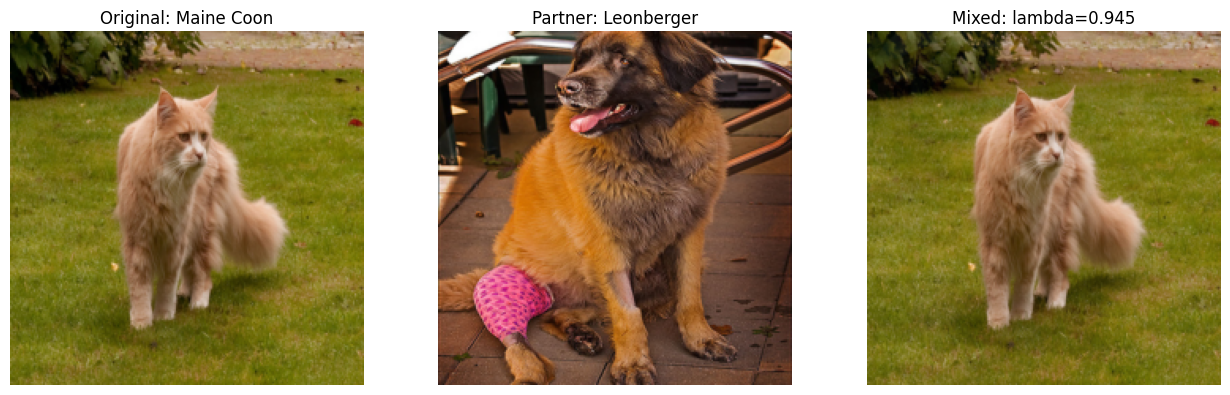

Mixed target: 0.945 × Maine Coon + 0.055 × Leonberger


In [35]:
images, labels = next(iter(train_loader))
mixed_images, labels_a, labels_b, lam, permutation = mixup_batch(
    images, labels, alpha=0.2, seed=SEED, return_permutation=True
)

sample_index = 0
partner_index = int(permutation[sample_index])

def denormalize_for_plot(image):
    mean = torch.tensor(IMAGENET_MEAN)[:, None, None]
    std = torch.tensor(IMAGENET_STD)[:, None, None]
    return (image.cpu() * std + mean).permute(1, 2, 0).clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(denormalize_for_plot(images[sample_index]))
axes[0].set_title(f"Original: {class_names[int(labels_a[sample_index])] }")
axes[1].imshow(denormalize_for_plot(images[partner_index]))
axes[1].set_title(f"Partner: {class_names[int(labels_b[sample_index])] }")
axes[2].imshow(denormalize_for_plot(mixed_images[sample_index]))
axes[2].set_title(f"Mixed: lambda={lam:.3f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(
    f"Mixed target: {lam:.3f} × {class_names[int(labels_a[sample_index])]} + "
    f"{1 - lam:.3f} × {class_names[int(labels_b[sample_index])]}"
)

The sampled value `lambda=0.945` makes the mixed image predominantly Maine Coon, with a 5.5% contribution from the Leonberger partner. Extreme mixtures are expected for `Beta(0.2, 0.2)`.

### Controlled plain-versus-mixup comparison

Both runs use the same frozen backbone, head initialization, data subset, optimizer settings, and epoch count. Validation remains deterministic and does not use mixup.

Plain | Epoch 01/8 | val acc: 52.4%
Plain | Epoch 02/8 | val acc: 72.6%
Plain | Epoch 03/8 | val acc: 80.7%
Plain | Epoch 04/8 | val acc: 82.4%
Plain | Epoch 05/8 | val acc: 81.4%
Plain | Epoch 06/8 | val acc: 80.7%
Plain | Epoch 07/8 | val acc: 84.5%
Plain | Epoch 08/8 | val acc: 86.1%
Mixup | Epoch 01/8 | train loss: 3.173 | val acc: 44.6%
Mixup | Epoch 02/8 | train loss: 1.740 | val acc: 70.3%
Mixup | Epoch 03/8 | train loss: 1.452 | val acc: 78.0%
Mixup | Epoch 04/8 | train loss: 1.146 | val acc: 80.4%
Mixup | Epoch 05/8 | train loss: 0.969 | val acc: 78.4%
Mixup | Epoch 06/8 | train loss: 0.852 | val acc: 81.1%
Mixup | Epoch 07/8 | train loss: 0.877 | val acc: 84.1%
Mixup | Epoch 08/8 | train loss: 0.961 | val acc: 84.8%
Best plain validation accuracy: 86.1%
Best mixup validation accuracy: 84.8%


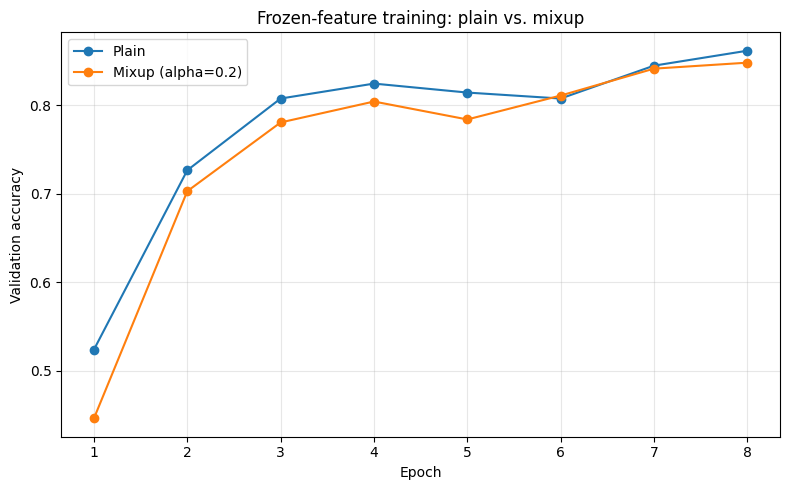

In [36]:
def run_mixup_train_epoch(model, loader, loss_fn, optimizer, alpha=0.2):
    model.eval()
    for module in model.trainable_modules:
        module.train()

    total_loss = 0.0
    total_examples = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        mixed_images, labels_a, labels_b, lam = mixup_batch(images, labels, alpha=alpha)
        logits = model(mixed_images)
        loss = mixup_loss(loss_fn, logits, labels_a, labels_b, lam)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


MIXUP_EPOCHS = 8

# Plain frozen-feature model.
set_seed(SEED)
plain_train_loader = make_loader(train_dataset_aug, shuffle=True, seed=SEED)
plain_model, plain_optimizer = make_finetune_model("none")
plain_history = {"val_accuracy": []}
plain_best_state = None
plain_best_accuracy = -1.0

for epoch in range(MIXUP_EPOCHS):
    run_epoch(plain_model, plain_train_loader, loss_fn, optimizer=plain_optimizer)
    val_metrics = run_epoch(plain_model, val_loader, loss_fn)
    plain_history["val_accuracy"].append(val_metrics["accuracy"])
    if val_metrics["accuracy"] > plain_best_accuracy:
        plain_best_accuracy = val_metrics["accuracy"]
        plain_best_state = deepcopy(plain_model.state_dict())
    print(f"Plain | Epoch {epoch + 1:02d}/{MIXUP_EPOCHS} | val acc: {val_metrics['accuracy']:.1%}")

plain_model.load_state_dict(plain_best_state)

# Frozen-feature model trained with mixup from the same random initialization.
set_seed(SEED)
mixup_train_loader = make_loader(train_dataset_aug, shuffle=True, seed=SEED)
mixup_model, mixup_optimizer = make_finetune_model("none")
mixup_history = {"val_accuracy": []}
mixup_best_state = None
mixup_best_accuracy = -1.0

for epoch in range(MIXUP_EPOCHS):
    train_loss = run_mixup_train_epoch(
        mixup_model, mixup_train_loader, loss_fn, mixup_optimizer, alpha=0.2
    )
    val_metrics = run_epoch(mixup_model, val_loader, loss_fn)
    mixup_history["val_accuracy"].append(val_metrics["accuracy"])
    if val_metrics["accuracy"] > mixup_best_accuracy:
        mixup_best_accuracy = val_metrics["accuracy"]
        mixup_best_state = deepcopy(mixup_model.state_dict())
    print(
        f"Mixup | Epoch {epoch + 1:02d}/{MIXUP_EPOCHS} | "
        f"train loss: {train_loss:.3f} | val acc: {val_metrics['accuracy']:.1%}"
    )

mixup_model.load_state_dict(mixup_best_state)

print(f"Best plain validation accuracy: {plain_best_accuracy:.1%}")
print(f"Best mixup validation accuracy: {mixup_best_accuracy:.1%}")

plt.figure(figsize=(8, 5))
epochs = range(1, MIXUP_EPOCHS + 1)
plt.plot(epochs, plain_history["val_accuracy"], marker="o", label="Plain")
plt.plot(epochs, mixup_history["val_accuracy"], marker="o", label="Mixup (alpha=0.2)")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Frozen-feature training: plain vs. mixup")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Results and conclusion

| Experiment | Trainable parameters | Best validation accuracy |
|---|---:|---:|
| Frozen backbone | 18,981 | 86.1% |
| Fine-tune `layer4` | 8,412,709 | 86.5% |
| Fine-tune `layer4`, frozen BN statistics | 8,412,709 | **87.2%** |
| Fine-tune all layers | 11,195,493 | 85.5% |
| Frozen backbone + mixup | 18,981 | 84.8% |

Selective fine-tuning provides the strongest result. Adapting only the final residual stage gives the model enough flexibility to refine high-level ImageNet features while retaining general low-level representations. Freezing BatchNorm statistics is helpful in this small-data setting, where per-batch estimates are noisy.

Full fine-tuning and mixup do not improve validation accuracy under the tested eight-epoch schedule. These outcomes should be interpreted cautiously because the experiments use one seed and only 20 training images per class. A production follow-up should repeat the comparison across multiple seeds and larger class-balanced subsets.

## References

- Yosinski et al., [How transferable are features in deep neural networks?](https://arxiv.org/abs/1411.1792)
- Selvaraju et al., [Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization](https://arxiv.org/abs/1610.02391)
- Zhang et al., [mixup: Beyond Empirical Risk Minimization](https://arxiv.org/abs/1710.09412)
- He et al., [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)